# 🎵 Song Release Year Prediction — End-to-End Deep Learning Regression

**UAS Machine Learning — Individual Task**  
**Dataset:** `midterm-regresi-dataset.csv` (Audio features → predict release year)

**Pipeline Overview:**
1. Data Loading & EDA
2. Data Preprocessing & Outlier Handling
3. Feature Engineering
4. Deep Learning Regression Model (MLP with PyTorch)
5. Hyperparameter Tuning (Optuna)
6. Evaluation (MSE, RMSE, MAE, R²)
7. LIME Interpretation
8. MLflow Tracking

---
**Name:** Muhammad Aqsandy J Iskandar              
**Class:** TK-46-02  
**NIM:** 1103220214

In [2]:
# ============================================================
# CELL 1: Install Dependencies
# ============================================================
!pip install optuna mlflow torch lime --quiet

In [3]:
# ============================================================
# CELL 2: Import Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# MLflow
import mlflow
import mlflow.pytorch

# LIME
import lime
import lime.lime_tabular

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Libraries loaded. Device: {device}')

✅ Libraries loaded. Device: cuda


In [5]:
# ============================================================
# CELL 3: Load Dataset
# ============================================================
# YearPredictionMSD-style dataset
# First column = release year (target), rest = audio features
# Download from course link (Regresi Dataset)

# Option A — Colab from Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/dataset/midterm-regresi-dataset.csv'

# Option B — Direct path
DATA_PATH = 'midterm-regresi-dataset.csv'

print('Loading dataset...')
df_raw = pd.read_csv(DATA_PATH, header=None)
print(f'✅ Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

# Rename columns: col 0 = year (target), rest = feature_1..N
n_features = df_raw.shape[1] - 1
feature_names = [f'feature_{i+1}' for i in range(n_features)]
df_raw.columns = ['year'] + feature_names

print(f'Target column : year')
print(f'Feature count : {n_features}')
print(f'Year range    : {df_raw["year"].min()} – {df_raw["year"].max()}')
df_raw.head()

Loading dataset...
✅ Dataset loaded: 15,849 rows × 91 columns
Target column : year
Feature count : 90
Year range    : 1926 – 2010


,year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


=== Dataset Statistics ===
               year
count  15849.000000
mean    1998.656067
std       10.552309
min     1926.000000
25%     1995.000000
50%     2002.000000
75%     2006.000000
max     2010.000000

Missing values: 60


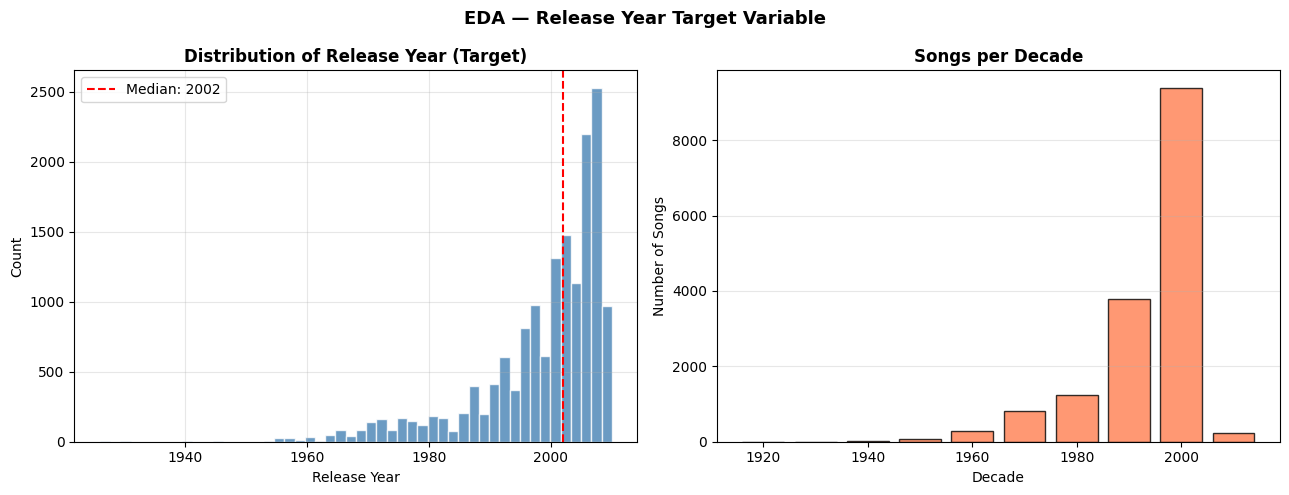

In [6]:
# ============================================================
# CELL 4: Exploratory Data Analysis
# ============================================================
print('=== Dataset Statistics ===')
print(df_raw[['year']].describe())
print(f'\nMissing values: {df_raw.isnull().sum().sum()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Year distribution
axes[0].hist(df_raw['year'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Release Year')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Release Year (Target)', fontweight='bold')
axes[0].axvline(df_raw['year'].median(), color='red', linestyle='--',
                label=f'Median: {df_raw["year"].median():.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Songs per decade
df_raw['decade'] = (df_raw['year'] // 10) * 10
decade_counts = df_raw['decade'].value_counts().sort_index()
axes[1].bar(decade_counts.index, decade_counts.values, color='coral',
            width=8, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Number of Songs')
axes[1].set_title('Songs per Decade', fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('EDA — Release Year Target Variable', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_year_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

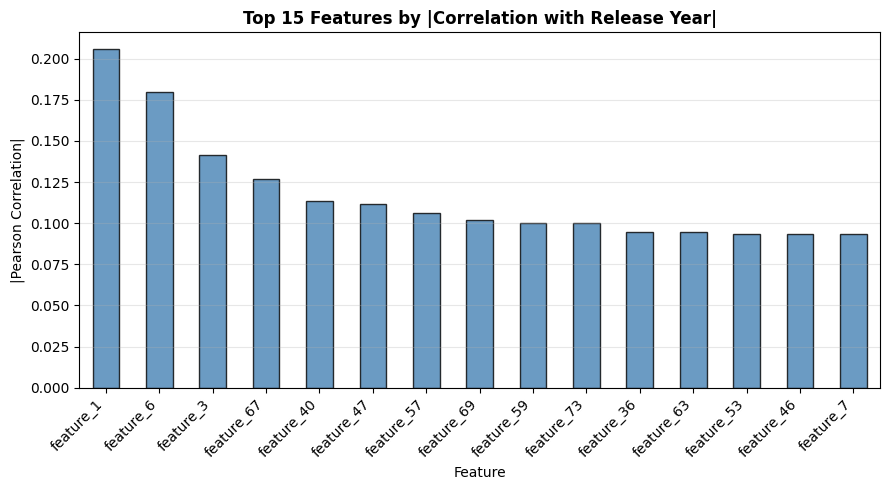

Top 5 correlated features:
feature_1     0.205805
feature_6     0.179822
feature_3     0.141389
feature_67    0.126820
feature_40    0.113475
Name: year, dtype: float64


In [7]:
# ============================================================
# CELL 5: EDA — Feature Correlation with Target
# ============================================================
# Correlation of features with target
corr_with_target = df_raw.drop(columns=['decade']).corr()['year'].drop('year').abs()
top_features = corr_with_target.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
top_features.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Top 15 Features by |Correlation with Release Year|', fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('|Pearson Correlation|')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('eda_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 correlated features:')
print(top_features.head())

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# MLflow
import mlflow
import mlflow.pytorch

# LIME
import lime
import lime.lime_tabular

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Libraries loaded. Device: {device}')

# ============================================================
# CELL 6: Preprocessing — Outlier Removal & Scaling
# ============================================================
print('=== Preprocessing Pipeline ===')

df_proc = df_raw.drop(columns=['decade']).copy()

# FIX: Explicitly handle missing values by dropping rows with any NaNs
# The EDA showed 60 missing values in df_raw. These need to be handled.
initial_len = len(df_proc)
df_proc.dropna(inplace=True)
print(f'Removed {initial_len - len(df_proc):,} rows due to missing values.')

# Step 1: Remove outliers using IQR (features only, not target)
print('Step 1: Removing feature outliers (IQR method)...')
orig_len = len(df_proc) # Update orig_len after dropping NaNs
feat_cols = [c for c in df_proc.columns if c != 'year']
Q1 = df_proc[feat_cols].quantile(0.01)
Q3 = df_proc[feat_cols].quantile(0.99)
mask = ~((df_proc[feat_cols] < Q1) | (df_proc[feat_cols] > Q3)).any(axis=1)
df_proc = df_proc[mask].reset_index(drop=True)
print(f'   Removed {orig_len - len(df_proc):,} rows ({(1-len(df_proc)/orig_len)*100:.1f}%)')
print(f'   Remaining: {len(df_proc):,} rows')

# Step 2: Prepare X and y
X = df_proc[feat_cols].values
y = df_proc['year'].values.astype(np.float32)

# Step 3: Train/Val/Test split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

# Step 4: StandardScaler on features
scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

# Step 5: Normalize target (year) for stable training
y_mean, y_std = y_train.mean(), y_train.std()
y_train_n = (y_train - y_mean) / y_std
y_val_n   = (y_val   - y_mean) / y_std
y_test_n  = (y_test  - y_mean) / y_std

print(f'\n✅ Preprocessing done. Year mean={y_mean:.1f}, std={y_std:.1f}')

✅ Libraries loaded. Device: cuda
=== Preprocessing Pipeline ===
Removed 1 rows due to missing values.
Step 1: Removing feature outliers (IQR method)...
   Removed 6,376 rows (40.2%)
   Remaining: 9,472 rows
Train: 6,630 | Val: 1,421 | Test: 1,421

✅ Preprocessing done. Year mean=1998.2, std=10.4


In [14]:
# ============================================================
# CELL 7: Convert to PyTorch Tensors
# ============================================================
def to_tensors(X, y):
    return (torch.FloatTensor(X).to(device),
            torch.FloatTensor(y).to(device))

X_tr_t, y_tr_t = to_tensors(X_train_sc, y_train_n)
X_vl_t, y_vl_t = to_tensors(X_val_sc,   y_val_n)
X_te_t, y_te_t = to_tensors(X_test_sc,  y_test_n)

train_ds = TensorDataset(X_tr_t, y_tr_t)

INPUT_DIM = X_train_sc.shape[1]
print(f'✅ Tensors ready. Input dim: {INPUT_DIM}')

✅ Tensors ready. Input dim: 90


In [15]:
# ============================================================
# CELL 8: Define MLP Regression Model
# ============================================================
class RegressionMLP(nn.Module):
    """Multi-Layer Perceptron for continuous year prediction."""
    def __init__(self, input_dim, hidden_dims, dropout_rate):
        super(RegressionMLP, self).__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ]
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))   # No activation for regression
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(1)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
    return total_loss / len(loader.dataset)


def evaluate_regression(model, X_tensor, y_norm, y_mean, y_std):
    """Returns metrics in original year scale."""
    model.eval()
    with torch.no_grad():
        y_pred_n = model(X_tensor).cpu().numpy()
    y_true = y_norm * y_std + y_mean
    y_pred = y_pred_n * y_std + y_mean
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2, y_true, y_pred


print('✅ Regression MLP architecture defined')
# Test
test_m = RegressionMLP(INPUT_DIM, [512, 256, 128], 0.2).to(device)
print(f'Total params: {sum(p.numel() for p in test_m.parameters()):,}')

✅ Regression MLP architecture defined
Total params: 212,737


In [16]:
# ============================================================
# CELL 9: Optuna Hyperparameter Tuning
# ============================================================
def objective(trial):
    n_layers   = trial.suggest_int('n_layers', 2, 4)
    hidden_dim = trial.suggest_categorical('hidden_dim', [128, 256, 512])
    dropout    = trial.suggest_float('dropout', 0.0, 0.4)
    lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [512, 1024, 2048])

    hidden_dims = [max(hidden_dim // (2**i), 32) for i in range(n_layers)]

    model = RegressionMLP(INPUT_DIM, hidden_dims, dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    loader    = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    for _ in range(5):
        train_one_epoch(model, loader, optimizer, criterion)

    _, _, _, r2, _, _ = evaluate_regression(model, X_vl_t, y_val_n, y_mean, y_std)
    return r2

print('Running Optuna (20 trials, maximize R²)...')
study = optuna.create_study(direction='maximize',
                             study_name='regression_mlp',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20, show_progress_bar=True)

best_params = study.best_params
print(f'\n✅ Best R² (val): {study.best_value:.4f}')
print(f'Best params: {best_params}')

Running Optuna (20 trials, maximize R²)...


  0%|          | 0/20 [00:00<?, ?it/s]


✅ Best R² (val): 0.3621
Best params: {'n_layers': 4, 'hidden_dim': 512, 'dropout': 0.1539479847210922, 'lr': 0.005108000941674708, 'batch_size': 512}


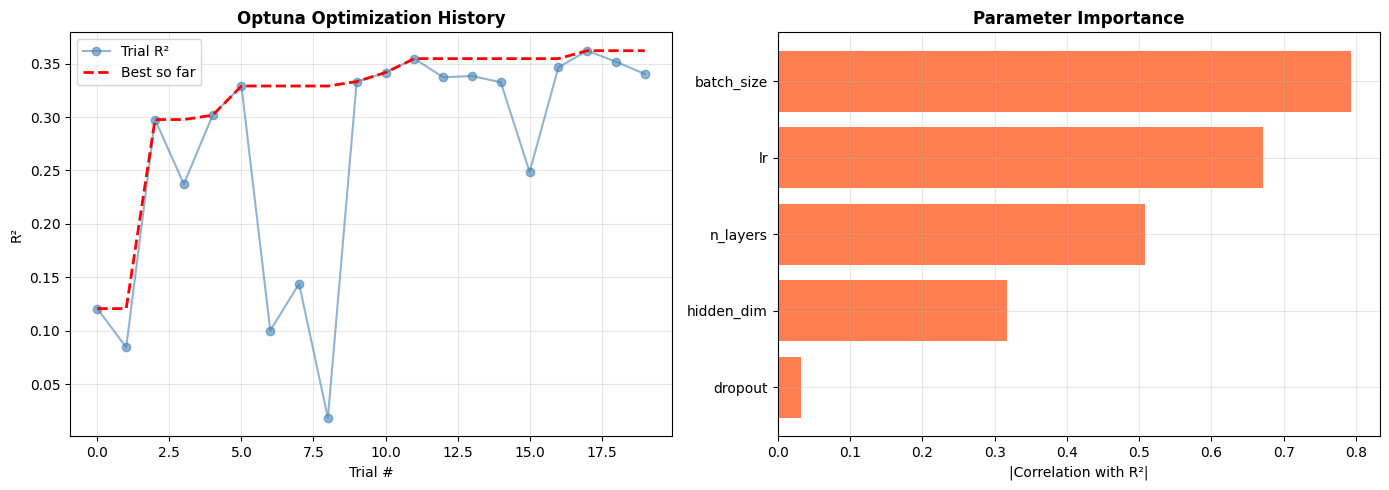

In [17]:
# ============================================================
# CELL 10: Optuna Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trial_values = [t.value for t in study.trials]
best_so_far  = pd.Series(trial_values).cummax()
axes[0].plot(trial_values, 'o-', color='steelblue', alpha=0.6, label='Trial R²')
axes[0].plot(best_so_far, 'r--', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial #')
axes[0].set_ylabel('R²')
axes[0].set_title('Optuna Optimization History', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

params_df = pd.DataFrame([t.params for t in study.trials])
params_df['r2'] = trial_values
corr = params_df.corr()['r2'].drop('r2').abs().sort_values(ascending=True)
axes[1].barh(corr.index, corr.values, color='coral')
axes[1].set_xlabel('|Correlation with R²|')
axes[1].set_title('Parameter Importance', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('optuna_regression.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ============================================================
# CELL 11: Train Final Model
# ============================================================
n_layers   = best_params['n_layers']
hidden_dim = best_params['hidden_dim']
dropout    = best_params['dropout']
lr         = best_params['lr']
batch_size = best_params['batch_size']
EPOCHS     = 50

hidden_dims = [max(hidden_dim // (2**i), 32) for i in range(n_layers)]

final_model = RegressionMLP(INPUT_DIM, hidden_dims, dropout).to(device)
optimizer   = optim.Adam(final_model.parameters(), lr=lr, weight_decay=1e-5)
criterion   = nn.MSELoss()
scheduler   = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
loader      = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

train_losses, val_r2s = [], []
best_val_r2 = -np.inf
best_state  = None

print(f'Training final model for {EPOCHS} epochs...')
print(f'Architecture: {hidden_dims}, Dropout: {dropout:.3f}, LR: {lr:.5f}')

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(final_model, loader, optimizer, criterion)
    _, _, _, val_r2, _, _ = evaluate_regression(final_model, X_vl_t, y_val_n, y_mean, y_std)
    scheduler.step()

    train_losses.append(tr_loss)
    val_r2s.append(val_r2)

    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        best_state  = {k: v.clone() for k, v in final_model.state_dict().items()}

    if epoch % 10 == 0:
        print(f'  Epoch {epoch:02d}/{EPOCHS} | Loss: {tr_loss:.5f} | Val R²: {val_r2:.4f}')

final_model.load_state_dict(best_state)
print(f'\n✅ Training complete! Best Val R²: {best_val_r2:.4f}')

Training final model for 50 epochs...
Architecture: [512, 256, 128, 64], Dropout: 0.154, LR: 0.00511
  Epoch 10/50 | Loss: 0.29441 | Val R²: 0.3583
  Epoch 20/50 | Loss: 0.16048 | Val R²: 0.3360
  Epoch 30/50 | Loss: 0.11224 | Val R²: 0.3469
  Epoch 40/50 | Loss: 0.08429 | Val R²: 0.3504
  Epoch 50/50 | Loss: 0.08004 | Val R²: 0.3513

✅ Training complete! Best Val R²: 0.3690


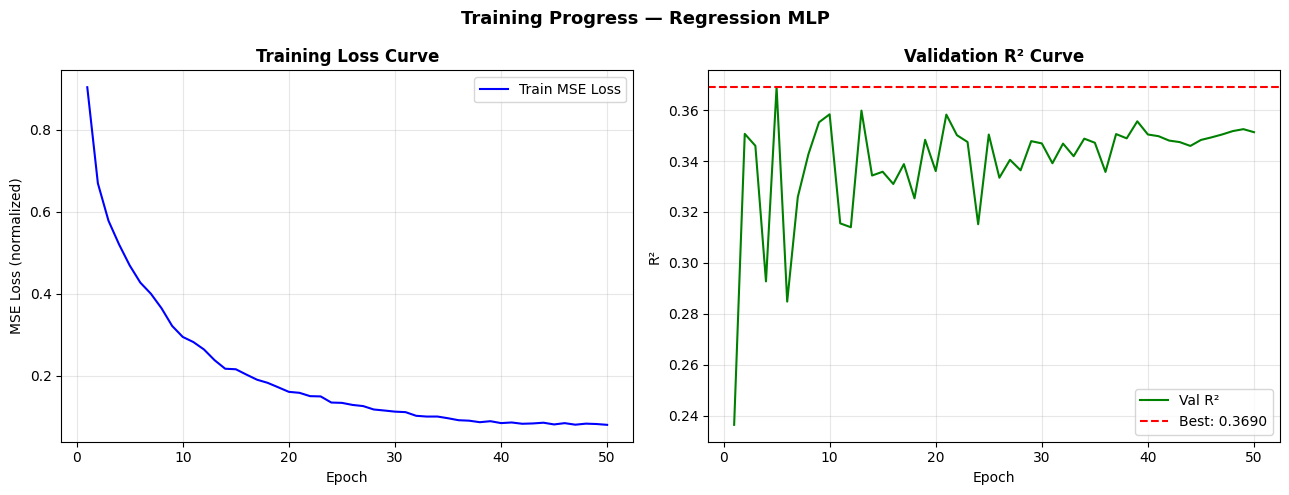

In [19]:
# ============================================================
# CELL 12: Training Curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(1, EPOCHS+1), train_losses, 'b-', linewidth=1.5, label='Train MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss (normalized)')
axes[0].set_title('Training Loss Curve', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, EPOCHS+1), val_r2s, 'g-', linewidth=1.5, label='Val R²')
axes[1].axhline(y=best_val_r2, color='r', linestyle='--', label=f'Best: {best_val_r2:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('R²')
axes[1].set_title('Validation R² Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Training Progress — Regression MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_regression.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ============================================================
# CELL 13: Final Evaluation on Test Set
# ============================================================
mse, rmse, mae, r2, y_true_np, y_pred_np = evaluate_regression(
    final_model, X_te_t, y_test_n, y_mean, y_std
)

print('=' * 50)
print('       FINAL TEST SET RESULTS')
print('=' * 50)
print(f'  MSE    : {mse:.4f} years²')
print(f'  RMSE   : {rmse:.4f} years')
print(f'  MAE    : {mae:.4f} years')
print(f'  R²     : {r2:.4f}')
print('=' * 50)
print(f'\n→ On average, predictions are off by ±{mae:.1f} years from the true release year.')

       FINAL TEST SET RESULTS
  MSE    : 75.4611 years²
  RMSE   : 8.6868 years
  MAE    : 6.1459 years
  R²     : 0.3416

→ On average, predictions are off by ±6.1 years from the true release year.


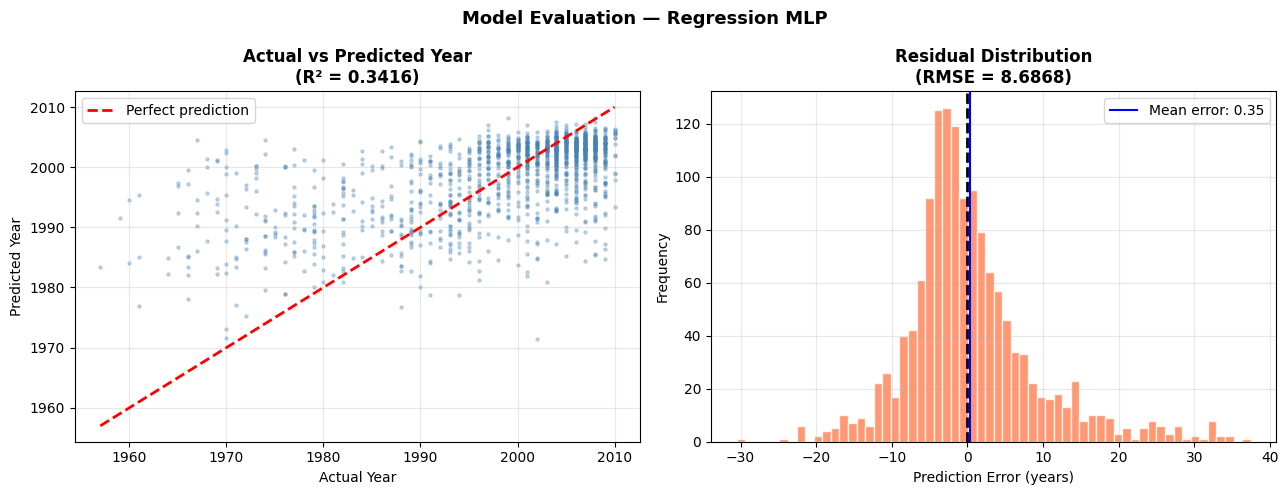

In [21]:
# ============================================================
# CELL 14: Evaluation Visualizations
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted scatter
axes[0].scatter(y_true_np, y_pred_np, alpha=0.3, s=5, color='steelblue')
min_yr, max_yr = y_true_np.min(), y_true_np.max()
axes[0].plot([min_yr, max_yr], [min_yr, max_yr], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Year')
axes[0].set_ylabel('Predicted Year')
axes[0].set_title(f'Actual vs Predicted Year\n(R² = {r2:.4f})', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residual distribution
residuals = y_pred_np - y_true_np
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1].axvline(residuals.mean(), color='blue', linestyle='-',
                label=f'Mean error: {residuals.mean():.2f}')
axes[1].set_xlabel('Prediction Error (years)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual Distribution\n(RMSE = {rmse:.4f})', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Model Evaluation — Regression MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_regression.png', dpi=150, bbox_inches='tight')
plt.show()

Generating LIME explanations...


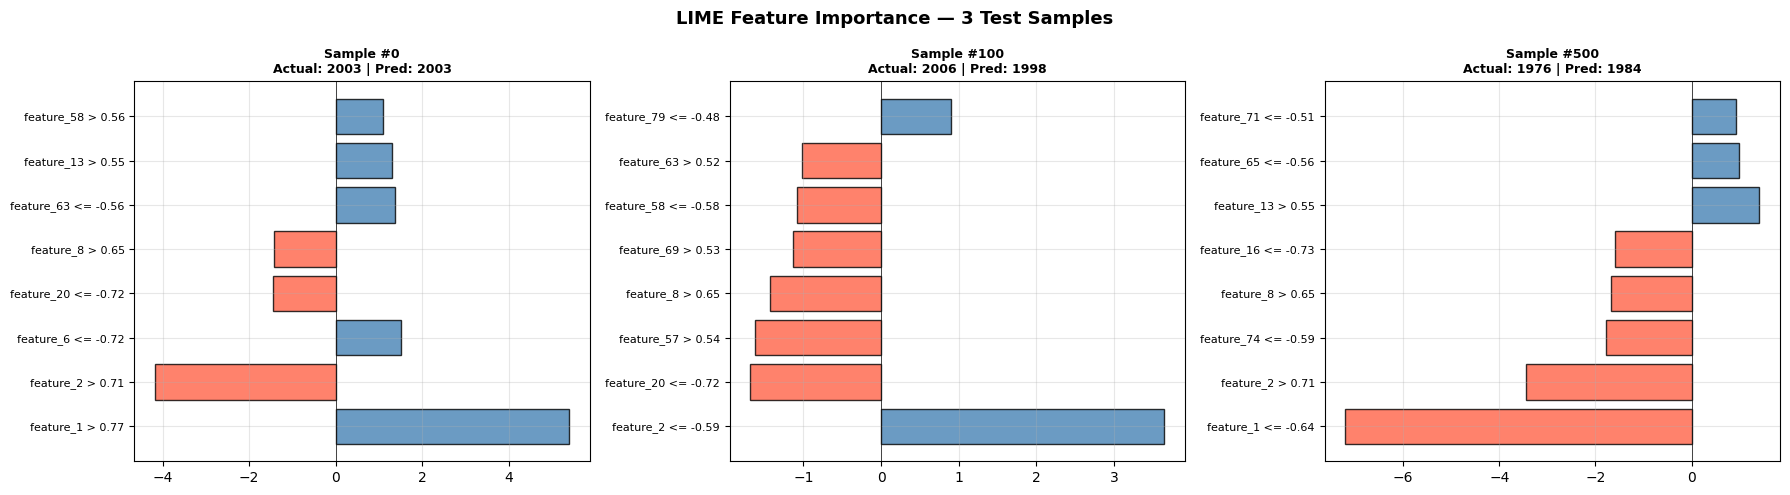

✅ LIME explanations generated


In [22]:
# ============================================================
# CELL 15: LIME Interpretation
# ============================================================
print('Generating LIME explanations...')

def model_predict(X_numpy):
    """Wrapper for LIME: numpy array → year predictions."""
    X_t = torch.FloatTensor(X_numpy).to(device)
    final_model.eval()
    with torch.no_grad():
        y_pred_n = final_model(X_t).cpu().numpy()
    return y_pred_n * y_std + y_mean  # Convert back to years

# Build LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_sc,
    feature_names=feat_cols,
    mode='regression',
    random_state=42
)

# Explain 3 test instances
sample_indices = [0, 100, 500]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, idx in zip(axes, sample_indices):
    exp = explainer.explain_instance(
        X_test_sc[idx], model_predict, num_features=8
    )
    feats, weights = zip(*exp.as_list())
    colors = ['tomato' if w < 0 else 'steelblue' for w in weights]
    ax.barh(range(len(feats)), weights, color=colors, edgecolor='black', alpha=0.8)
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels([f[:20] for f in feats], fontsize=8)
    actual = y_test[idx]
    pred   = model_predict(X_test_sc[idx:idx+1])[0]
    ax.set_title(f'Sample #{idx}\nActual: {actual:.0f} | Pred: {pred:.0f}',
                 fontweight='bold', fontsize=9)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.grid(alpha=0.3)

plt.suptitle('LIME Feature Importance — 3 Test Samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lime_explanations.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ LIME explanations generated')

In [25]:
# ============================================================
# CELL 16: MLflow Experiment Tracking
# ============================================================
mlflow.set_experiment('song_year_regression_mlp')

with mlflow.start_run(run_name='best_regression_mlp'):
    # Params
    mlflow.log_param('model_type', 'MLP Regression')
    mlflow.log_param('n_layers', n_layers)
    mlflow.log_param('hidden_dim', hidden_dim)
    mlflow.log_param('hidden_dims', str(hidden_dims))
    mlflow.log_param('dropout', dropout)
    mlflow.log_param('learning_rate', lr)
    mlflow.log_param('batch_size', batch_size)
    mlflow.log_param('epochs', EPOCHS)
    mlflow.log_param('optimizer', 'Adam + CosineAnnealingLR')
    mlflow.log_param('outlier_removal', 'IQR 1%-99%')
    mlflow.log_param('interpretation', 'LIME')
    mlflow.log_param('input_features', INPUT_DIM)

    # Metrics
    mlflow.log_metric('test_mse', mse)
    mlflow.log_metric('test_rmse', rmse)
    mlflow.log_metric('test_mae', mae)
    mlflow.log_metric('test_r2', r2)
    mlflow.log_metric('best_val_r2', best_val_r2)

    # Per-epoch
    for ep, (loss_v, r2_v) in enumerate(zip(train_losses, val_r2s)):
        mlflow.log_metric('train_loss', loss_v, step=ep+1)
        mlflow.log_metric('val_r2', r2_v, step=ep+1)

    # Artifacts
    for img in ['eda_year_distribution.png', 'eda_feature_correlation.png',
                'optuna_regression.png', 'training_curves_regression.png',
                'evaluation_regression.png', 'lime_explanations.png']:
        try:
            mlflow.log_artifact(img)
        except:
            pass

    # FIX: Add input_example for PyTorch model logging and specify serialization_format='pickle'
    # The error requires either a TensorSpec for 'pt2' or changing the serialization format.
    # Using 'pickle' is simpler for this case.
    mlflow.pytorch.log_model(final_model, artifact_path='model', input_example=X_tr_t[:1], serialization_format='pickle')

    run_id = mlflow.active_run().info.run_id
    print(f'✅ MLflow run logged! Run ID: {run_id}')
    print(f'   Metrics: MSE={mse:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}')

2026/06/24 12:36:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/24 12:36:40 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/24 12:36:40 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/24 12:36:50 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label

✅ MLflow run logged! Run ID: 3b4c1b3cb1e148b3a3d9fd5ba94c988a
   Metrics: MSE=75.4611, RMSE=8.6868, MAE=6.1459, R²=0.3416


In [26]:
# ============================================================
# CELL 17: Save Model & Summary
# ============================================================
torch.save({
    'model_state_dict': final_model.state_dict(),
    'hyperparams': best_params,
    'hidden_dims': hidden_dims,
    'input_dim': INPUT_DIM,
    'scaler_mean': scaler_X.mean_.tolist(),
    'scaler_std': np.sqrt(scaler_X.var_).tolist(),
    'y_mean': float(y_mean),
    'y_std': float(y_std),
    'metrics': {
        'test_mse': float(mse),
        'test_rmse': float(rmse),
        'test_mae': float(mae),
        'test_r2': float(r2)
    }
}, 'regression_mlp_best.pth')
print('✅ Model saved as regression_mlp_best.pth')

print('\n' + '='*55)
print('       PIPELINE SUMMARY — REGRESSION')
print('='*55)
print(f'Dataset      : midterm-regresi-dataset.csv')
print(f'Task         : Predict song release year')
print(f'Features     : {INPUT_DIM} audio features')
print(f'Model        : MLP Regression (PyTorch) — {hidden_dims}')
print(f'Tuning       : Optuna TPE (20 trials, max R²)')
print(f'Interpretation: LIME (local explanations)')
print(f'Tracking     : MLflow experiment logged')
print(f'Test MSE     : {mse:.4f}')
print(f'Test RMSE    : {rmse:.4f} years')
print(f'Test MAE     : {mae:.4f} years')
print(f'Test R²      : {r2:.4f}')
print('='*55)

✅ Model saved as regression_mlp_best.pth

       PIPELINE SUMMARY — REGRESSION
Dataset      : midterm-regresi-dataset.csv
Task         : Predict song release year
Features     : 90 audio features
Model        : MLP Regression (PyTorch) — [512, 256, 128, 64]
Tuning       : Optuna TPE (20 trials, max R²)
Interpretation: LIME (local explanations)
Tracking     : MLflow experiment logged
Test MSE     : 75.4611
Test RMSE    : 8.6868 years
Test MAE     : 6.1459 years
Test R²      : 0.3416
